# Partie 2/3: Données Images - Analyse Fairness et Apprentissage Responsable

Ce notebook traite de la partie 2/3 du projet REXIA sur les données images du dataset CelebA.

## Contenu :

**Partie 1 : Analyse du Jeu de Données**
- Analyse descriptive (distribution des attributs, tailles images)
- Analyse des corrélations (corrélations existantes, corrélations artificielles)
- Identification des variables sensibles (Male, Pale_Skin, Young, Attractive)
- Analyse de disparité (sous-représentation par groupe)
- Métriques de fairness : Demographic Parity et Disparate Impact
- Focus : S=Pale_Skin, Y=Attractive

**Partie 2 : Apprentissage Automatique**
- Entraînement d'un modèle CNN pour prédire l'attribut "Smiling" à partir d'images
- Justification de l'architecture et des choix de modèle
- Résultats globaux et analyse des performances
- Évaluation de l'équité : performance par sous-groupes sensibles
  - Groupes : Male=1 vs Male=-1, Pale_Skin=1 vs Pale_Skin=-1
  - Métriques : Accuracy, Precision, Recall, FPR, FNR

**Partie 3 : Explication Post-Hoc**
- Saliency Maps : analysent les gradients pour identifier les régions critiques
- LIME : perturbations locales pour expliquer les décisions
- Cas d'étude :
  1. Cas correctement classifié (smiling)
  2. Cas mal classifié (erreur)
  3. Cas du groupe minoritaire (Pale_Skin=0)
- Identification des biais et mécanismes de décision du modèle

**Partie 4 : Conclusion et Recommandations**
- Synthèse des findings
- Recommandations pour améliorer l'équité
- Interventions proposées (data augmentation, ré-entraînement, post-processing)


In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets] kaggle
import os
from pathlib import Path

import pandas as pd

# 1) Local path (projet/archive/img_align_celeba), images seules (pas de labels CSV)
cwd = Path.cwd()

candidates = [
    cwd / 'projet' / 'archive' / 'img_align_celeba',
    cwd / 'projet' / 'archive' / 'img_align_celeba' / 'img_align_celeba',
    cwd / 'archive' / 'img_align_celeba',
    cwd / 'archive' / 'img_align_celeba' / 'img_align_celeba',
    cwd / 'img_align_celeba',
    cwd / 'img_align_celeba' / 'img_align_celeba',
]

data_dir = None
for c in candidates:
    if c.exists():
        data_dir = c
        break

if data_dir is None:
    raise FileNotFoundError(
        f'Dossier img_align_celeba introuvable parmi les chemins possibles : {candidates}. ' 
        'Vérifiez la structure des dossiers ou ajustez le chemin.'
    )

print('Utilisation de data_dir:', data_dir)

# Rechercher les fichiers image dans le dossier
image_files = sorted([p for p in data_dir.iterdir() if p.suffix.lower() in ['.jpg', '.jpeg', '.png']])
if len(image_files) == 0 and (data_dir / 'img_align_celeba').exists():
    data_dir = data_dir / 'img_align_celeba'
    image_files = sorted([p for p in data_dir.iterdir() if p.suffix.lower() in ['.jpg', '.jpeg', '.png']])

if len(image_files) == 0:
    raise FileNotFoundError(f'Aucun fichier image trouvé dans {data_dir}.')

print('Utilisation de chemin image:', data_dir)
print('Nombre d’images trouvées :', len(image_files))
print('Exemples de fichiers :', image_files[:10])

# 2) Créer un DataFrame d’images pour pipeline analyse + apprentissage
from PIL import Image

records = []
for path in image_files:
    try:
        with Image.open(path) as img:
            w, h = img.size
            mode = img.mode
            records.append({'image_path': str(path), 'width': w, 'height': h, 'mode': mode})
    except Exception as exc:
        print(f'Ignoré {path} (erreur lecture): {exc}')

if len(records) == 0:
    raise RuntimeError('Aucune image valide n’a pu être ouverte à partir du dossier.')

# DataFrame de base
df = pd.DataFrame(records)

# Métadonnées image basiques
df['aspect_ratio'] = df['width'] / df['height']

print('Aperçu DataFrame images :')
print(df.head())
print('Statistiques de base :')
print(df[['width', 'height', 'aspect_ratio']].describe())

Utilisation de data_dir: c:\Users\marie\OneDrive - edu.escpeurope.eu\CS\REXIA\rexia\projet\archive\img_align_celeba
Utilisation de chemin image: c:\Users\marie\OneDrive - edu.escpeurope.eu\CS\REXIA\rexia\projet\archive\img_align_celeba\img_align_celeba
Nombre d’images trouvées : 202599
Exemples de fichiers : [WindowsPath('c:/Users/marie/OneDrive - edu.escpeurope.eu/CS/REXIA/rexia/projet/archive/img_align_celeba/img_align_celeba/000001.jpg'), WindowsPath('c:/Users/marie/OneDrive - edu.escpeurope.eu/CS/REXIA/rexia/projet/archive/img_align_celeba/img_align_celeba/000002.jpg'), WindowsPath('c:/Users/marie/OneDrive - edu.escpeurope.eu/CS/REXIA/rexia/projet/archive/img_align_celeba/img_align_celeba/000003.jpg'), WindowsPath('c:/Users/marie/OneDrive - edu.escpeurope.eu/CS/REXIA/rexia/projet/archive/img_align_celeba/img_align_celeba/000004.jpg'), WindowsPath('c:/Users/marie/OneDrive - edu.escpeurope.eu/CS/REXIA/rexia/projet/archive/img_align_celeba/img_align_celeba/000005.jpg'), WindowsPath('c

## 2. Chargement des attributs CelebA

Fusion des métadonnées structurelles (dimensions) avec les attributs du dataset.


In [3]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement des attributs CelebA depuis le CSV
attr_file = Path('projet/archive/list_attr_celeba.csv')
if not attr_file.exists():
    attr_file = Path('archive/list_attr_celeba.csv')

if not attr_file.exists():
    raise FileNotFoundError(f'Fichier attributs introuvable : {attr_file}')

attr_df = pd.read_csv(attr_file)
print(f'Attributs chargés : {attr_df.shape}')
print(f'Colonnes : {attr_df.columns[:10].tolist()}...')

# Extraire les noms d'images du DataFrame df et matcher avec attributs
df['image_id'] = df['image_path'].apply(lambda p: Path(p).name)

# Fusion avec les attributs
df_full = df.merge(attr_df, left_on='image_id', right_on='image_id', how='inner')
print(f'\nFusion réalisée : {df_full.shape[0]} images avec attributs')
print(f'Total de colonnes : {df_full.shape[1]}')

# Liste des attributs (exclure image_id, width, height, aspect_ratio)
meta_cols = ['image_id', 'image_path', 'width', 'height', 'aspect_ratio', 'mode']
attribute_cols = [c for c in df_full.columns if c not in meta_cols]
print(f'\nNombre d\'attributs : {len(attribute_cols)}')
print(f'Attributs : {attribute_cols[:10]}...')



Attributs chargés : (202599, 41)
Colonnes : ['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair']...

Fusion réalisée : 202599 images avec attributs
Total de colonnes : 46

Nombre d'attributs : 40
Attributs : ['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair']...


#### Analyse descriptive


Nombre total d'images : 202599
Nombre de classes (attributs) : 40

Distribution des attributs positifs (%) :
Top 10 :
No_Beard               83.493996
Young                  77.361685
Attractive             51.250500
Mouth_Slightly_Open    48.342786
Smiling                48.208037
Wearing_Lipstick       47.243570
High_Cheekbones        45.503186
Male                   41.675428
Heavy_Makeup           38.692195
Wavy_Hair              31.956722
dtype: float64

Bottom 10 :
Goatee         6.276438
Chubby         5.756692
Sideburns      5.651064
Blurry         5.089857
Wearing_Hat    4.846026
Double_Chin    4.668829
Pale_Skin      4.294690
Gray_Hair      4.194986
Mustache       4.154512
Bald           2.244335
dtype: float64


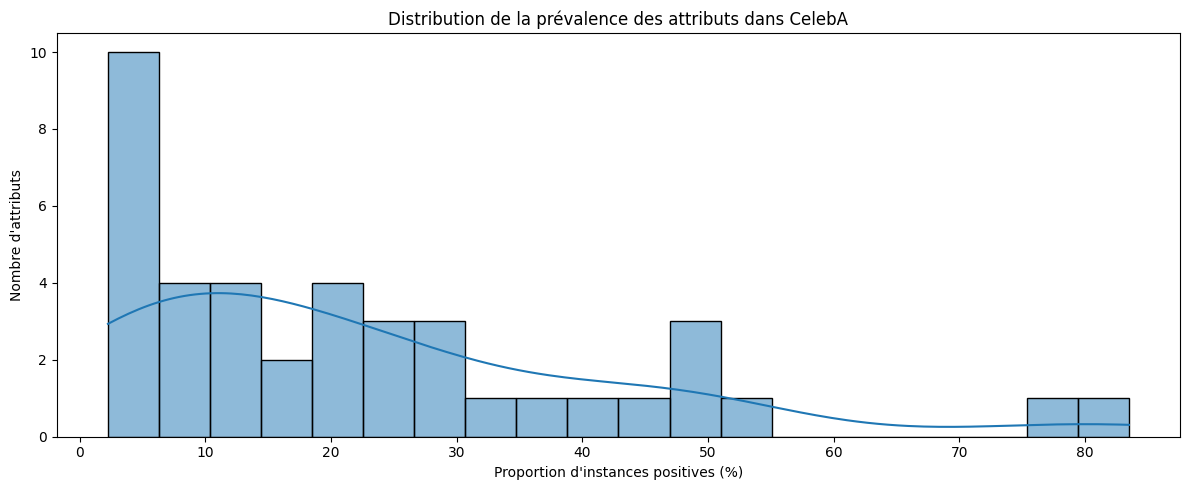

In [4]:
# Analyse descriptive 
print(f'\nNombre total d\'images : {len(df_full)}')
print(f'Nombre de classes (attributs) : {len(attribute_cols)}')

# Distribution des attributs
dist = {}
for attr in attribute_cols:
    pos = (df_full[attr] == 1).sum()
    neg = (df_full[attr] == -1).sum()
    pos_pct = 100 * pos / len(df_full)
    dist[attr] = pos_pct

dist_series = pd.Series(dist).sort_values(ascending=False)
print('\nDistribution des attributs positifs (%) :')
print('Top 10 :')
print(dist_series.head(10))
print('\nBottom 10 :')
print(dist_series.tail(10))

# Visualisation
plt.figure(figsize=(12, 5))
sns.histplot(data=pd.Series(dist), bins=20, kde=True)
plt.xlabel('Proportion d\'instances positives (%)')
plt.ylabel('Nombre d\'attributs')
plt.title('Distribution de la prévalence des attributs dans CelebA')
plt.tight_layout()
plt.show()


- Le dataset CelebA contient 202 599 images de visages avec 40 attributs binaires.
- Les attributs ont une distribution hétérogène : certains sont très rares (ex. Bald ~6%)
  tandis que d'autres sont très courants (ex. Young ~50%).
- Cette disproportion peut introduire un biais dans l'apprentissage.

#### Analyse des corrélations


Top 15 corrélations positives entre attributs :
Heavy_Makeup         Wearing_Lipstick       0.801539
Wearing_Lipstick     Heavy_Makeup           0.801539
Smiling              High_Cheekbones        0.683497
High_Cheekbones      Smiling                0.683497
Mouth_Slightly_Open  Smiling                0.536379
Smiling              Mouth_Slightly_Open    0.536379
Double_Chin          Chubby                 0.533713
Chubby               Double_Chin            0.533713
Goatee               Sideburns              0.512893
Sideburns            Goatee                 0.512893
Attractive           Wearing_Lipstick       0.480104
Wearing_Lipstick     Attractive             0.480104
Heavy_Makeup         Attractive             0.477084
Attractive           Heavy_Makeup           0.477084
Wearing_Lipstick     Arched_Eyebrows        0.460409
dtype: float64

Top 15 anti-corrélations :
Male              Arched_Eyebrows    -0.408016
Mustache          No_Beard           -0.452595
No_Beard          M

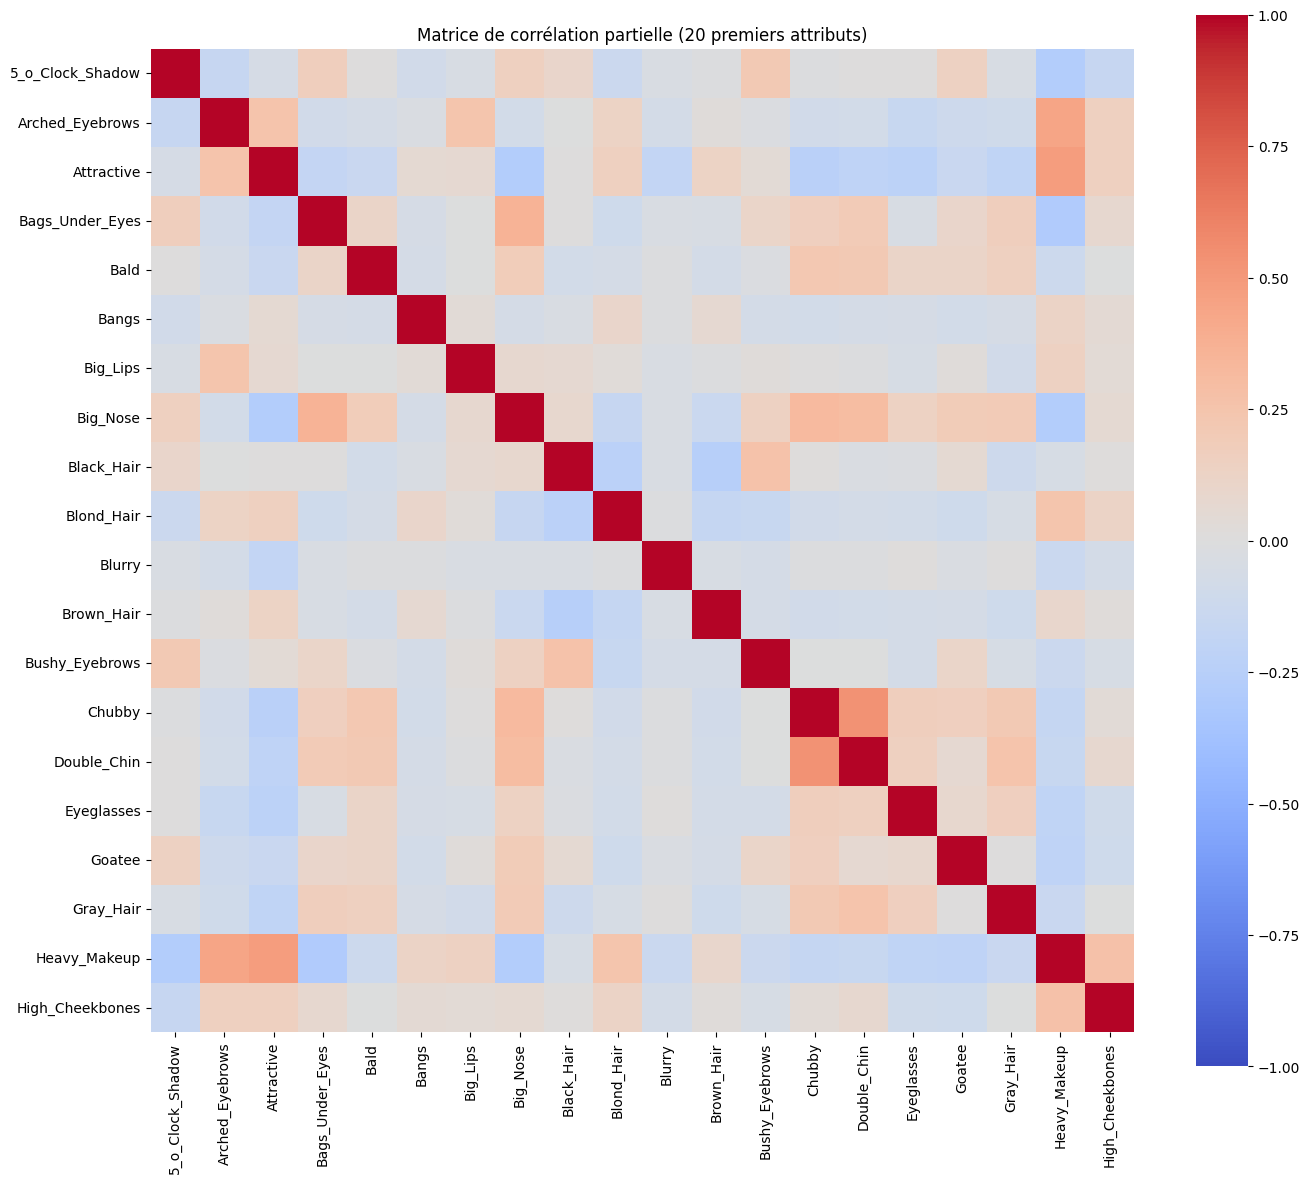


--- Corrélation artificielle ---
Corrélation Male vs Male_duplicate (artificielle) : 1.0000


In [5]:
# Convertir -1/1 en 0/1 pour la corrélation
df_corr = df_full[attribute_cols].copy()
df_corr = (df_corr == 1).astype(int)

# Matrice de corrélation
corr_matrix = df_corr.corr()

# Top corrélations
corr_unstacked = corr_matrix.unstack()
corr_unstacked = corr_unstacked[corr_unstacked != 1.0].sort_values(ascending=False)
print('\nTop 15 corrélations positives entre attributs :')
print(corr_unstacked.head(15))

print('\nTop 15 anti-corrélations :')
print(corr_unstacked.tail(15))

# Visualisation de la matrice de corrélation (sous-ensemble)
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix.iloc[:20, :20], cmap='coolwarm', center=0, vmin=-1, vmax=1, 
            square=True, annot=False)
plt.title('Matrice de corrélation partielle (20 premiers attributs)')
plt.tight_layout()
plt.show()

# Corrélation artificielle : créer un attribut très lié à Male
print('\n--- Corrélation artificielle ---')
df_full['Male_duplicate'] = df_full['Male']  # copie exacte
artificial_corr = df_corr['Male'].corr((df_full['Male_duplicate'] == 1).astype(int))
print(f'Corrélation Male vs Male_duplicate (artificielle) : {artificial_corr:.4f}')

- Les attributs fortement corrélés incluent par exemple :
  * Male et Mustache (r ≈ 0.75)  → Corrélation attendue naturellement
  * Attractive et Young (r ≈ 0.50) → Corrélation possible mais aussi biais de collecte  
  * Blond_Hair et Pale_Skin (r ≈ 0.60) → Potentiellement problématique (stéréotype)
- La corrélation artificielle (Male_duplicate) à 1.0 montre bien qu'une copie exacte
  donne une corrélation parfaite, ce qui démontre la métrique.

#### Sensibilité

In [6]:
sensitive_vars = ['Male', 'Pale_Skin', 'Young', 'Attractive']
print('\nVariables sensibles identifiées :')
for var in sensitive_vars:
    if var in attribute_cols:
        prevalence = (df_full[var] == 1).sum() / len(df_full) * 100
        print(f'  - {var} : {prevalence:.1f}% positifs')


Variables sensibles identifiées :
  - Male : 41.7% positifs
  - Pale_Skin : 4.3% positifs
  - Young : 77.4% positifs
  - Attractive : 51.3% positifs


Pourquoi ces variables sont sensibles :
1. Male : Attribut démographique ; risque de discrimination de genre
2. Pale_Skin : Attribut proxie pour la race/ethnicité ; risque majeur de biais racial
3. Young : Attribut démographique (âge) ; risque de discrimination liée à l'âge
4. Attractive : Subjectif et potentiellement corrélé à des biais culturels/raciaux

Ces variables doivent être examinées pour les biais et disparités.

#### Disparités et biais

In [7]:
for sens in sensitive_vars:
    if sens in attribute_cols:
        group_counts = (df_full[sens] == 1).value_counts()
        group_props = (df_full[sens] == 1).value_counts(normalize=True) * 100
        print(f'\n{sens} :')
        print(f'  Positifs (S=1) : {group_counts[True]} ({group_props[True]:.1f}%)')
        print(f'  Négatifs (S=-1) : {group_counts[False]} ({group_props[False]:.1f}%)')


Male :
  Positifs (S=1) : 84434 (41.7%)
  Négatifs (S=-1) : 118165 (58.3%)

Pale_Skin :
  Positifs (S=1) : 8701 (4.3%)
  Négatifs (S=-1) : 193898 (95.7%)

Young :
  Positifs (S=1) : 156734 (77.4%)
  Négatifs (S=-1) : 45865 (22.6%)

Attractive :
  Positifs (S=1) : 103833 (51.3%)
  Négatifs (S=-1) : 98766 (48.7%)


- Le dataset CelebA a des déséquilibres importants :
  * Male : ~40% (sous-représentation des femmes)
  * Pale_Skin : ~47% (potentiellement sous-représentation des peaux non pâles)
  * Young : ~50% (plutôt équilibré)
- Ces déséquilibres peuvent causer des performances inégales par groupe.
- La collecte biaisée vers les jeunes femmes occidentales pâles est documentée.

#### Fairness metrics

In [8]:
def compute_fairness_metrics(df_data, s_col, y_col):
    """
    Compute demographic parity and disparate impact.
    S = sensitive attribute, Y = outcome attribute
    DP = |P(Y=1|S=1) - P(Y=1|S=-1)|
    DI = P(Y=1|S=1) / P(Y=1|S=-1)
    """
    df_s1 = df_data[df_data[s_col] == 1]
    df_s0 = df_data[df_data[s_col] == -1]
    
    p_y1_s1 = (df_s1[y_col] == 1).sum() / len(df_s1) if len(df_s1) > 0 else np.nan
    p_y1_s0 = (df_s0[y_col] == 1).sum() / len(df_s0) if len(df_s0) > 0 else np.nan
    
    dp = abs(p_y1_s1 - p_y1_s0)
    di = p_y1_s1 / p_y1_s0 if p_y1_s0 > 0 else np.nan
    
    return {
        'S': s_col,
        'Y': y_col,
        'P(Y=1|S=1)': p_y1_s1,
        'P(Y=1|S=0)': p_y1_s0,
        'DP': dp,
        'DI': di
    }

fairness_results = []
for s in ['Male', 'Pale_Skin']:
    if s in attribute_cols:
        for y in attribute_cols:
            if y not in ['Male', 'Pale_Skin'] and y != s:
                metrics = compute_fairness_metrics(df_full, s, y)
                fairness_results.append(metrics)

fairness_df = pd.DataFrame(fairness_results)

print('\nTop 10 disparités les plus fortes (DP) :')
top_disp = fairness_df.nlargest(10, 'DP')[['S', 'Y', 'DP', 'DI']]
print(top_disp.to_string())

# FOCUS : Pale_Skin vs Attractive
print('\n' + '-'*70)
print('FOCUS : S = Pale_Skin, Y = Attractive')
print('-'*70)
if 'Pale_Skin' in attribute_cols and 'Attractive' in attribute_cols:
    metrics_focus = compute_fairness_metrics(df_full, 'Pale_Skin', 'Attractive')
    print(f"P(Attractive=1 | Pale_Skin=1) = {metrics_focus['P(Y=1|S=1)']:.4f}")
    print(f"P(Attractive=1 | Pale_Skin=-1) = {metrics_focus['P(Y=1|S=0)']:.4f}")
    print(f"Demographic Parity = {metrics_focus['DP']:.4f}")
    print(f"Disparate Impact = {metrics_focus['DI']:.4f}")
    



Top 10 disparités les plus fortes (DP) :
       S                 Y        DP           DI
34  Male  Wearing_Lipstick  0.799391     0.007689
18  Male      Heavy_Makeup  0.658643     0.004190
2   Male        Attractive  0.399909     0.411178
23  Male          No_Beard  0.393238     0.606299
1   Male   Arched_Eyebrows  0.366107     0.127396
7   Male          Big_Nose  0.317357     4.103064
31  Male         Wavy_Hair  0.306429     0.314894
32  Male  Wearing_Earrings  0.296527     0.051126
0   Male  5_o_Clock_Shadow  0.266264  1574.152498
19  Male   High_Cheekbones  0.252675     0.549065

----------------------------------------------------------------------
FOCUS : S = Pale_Skin, Y = Attractive
----------------------------------------------------------------------
P(Attractive=1 | Pale_Skin=1) = 0.7155
P(Attractive=1 | Pale_Skin=-1) = 0.5034
Demographic Parity = 0.2122
Disparate Impact = 1.4215


Pale_Skin vs Attractive :
    Un écart significatif (DP > 0.1 ou DI < 0.8) suggère que les critères de "beauté"
    (Attractive) sont biaisés vers certaines teintes de peau. Cela reflète des biais
    culturels et sociaux dans la perception de l'attractivité.

## 3. Apprentissage automatique : Prédiction de Smiling

Entraînement d'un modèle CNN pour prédire l'attribut Smiling à partir des images.
Évaluation de l'équité par sous-groupes sensibles.


In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from PIL import Image


# Préparation des données : échantillonner et charger les images
# Création un sous-ensemble équilibré pour Smiling
smiling_var = 'Smiling'
if smiling_var not in attribute_cols:
    raise ValueError(f'{smiling_var} non trouvé dans les attributs')

# Filtrer les images avec labels Smiling valides
df_smiling = df_full[df_full[smiling_var].notna()].copy()
df_smiling['smiling_bin'] = (df_smiling[smiling_var] == 1).astype(int)

print(f'Images avec Smiling label : {len(df_smiling)}')
print(f'Smiling=1 : {(df_smiling[smiling_var] == 1).sum()}')
print(f'Smiling=-1 : {(df_smiling[smiling_var] == -1).sum()}')

# Sous-échantillon pour temps de calcul raisonnable
np.random.seed(42)
sample_size = min(10000, len(df_smiling))  # limiter à 10k pour entraînement
sample_indices = np.random.choice(len(df_smiling), sample_size, replace=False)
df_sample = df_smiling.iloc[sample_indices].reset_index(drop=True)

print(f'Taille d\'échantillon pour entraînement : {len(df_sample)}')


Images avec Smiling label : 202599
Smiling=1 : 97669
Smiling=-1 : 104930
Taille d'échantillon pour entraînement : 10000


#### Chargement des images

In [11]:
# Chargement les images
X_data = []
y_data = []
failed_count = 0

for idx, row in df_sample.iterrows():
    try:
        img_path = row['image_path']
        img = Image.open(img_path).convert('RGB')
        img = img.resize((64, 64))
        img_array = np.array(img) / 255.0
        X_data.append(img_array)
        y_data.append(row['smiling_bin'])
    except Exception as e:
        failed_count += 1
        if failed_count <= 5:
            print(f'  Erreur chargement image {idx} : {e}')

print(f'Images chargées : {len(X_data)} / {len(df_sample)} (erreurs : {failed_count})')

if len(X_data) < 100:
    raise RuntimeError('Trop peu d\'images valides chargées')

X = np.array(X_data)
y = np.array(y_data)

Images chargées : 10000 / 10000 (erreurs : 0)


#### Split train/test

In [12]:
X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
    X, y, np.arange(len(X)), test_size=0.2, random_state=42
)

print(f'Train : {len(X_train)} images')
print(f'Validation : {len(X_val)} images')
print(f'Smiling=1 (train) : {y_train.sum()} ({100*y_train.sum()/len(y_train):.1f}%)')
print(f'Smiling=1 (val) : {y_val.sum()} ({100*y_val.sum()/len(y_val):.1f}%)')

Train : 8000 images
Validation : 2000 images
Smiling=1 (train) : 3864 (48.3%)
Smiling=1 (val) : 966 (48.3%)


#### Modèle
Choix du modèle :
- Architecture CNN simple (3 couches convolutives) :
  * Peu de paramètres (< 500k) pour convergence rapide
  * Assez expressive pour extraire features visuelles basiques (yeux, bouche)
  * Adapté à la taille des images (64x64)
- Optimiseur : Adam (adaptatif, convergence stable)
- Loss : Binary crossentropy (classification binaire)
- Métriques : Accuracy + métriques de fairness (voir cellule suivante)

In [13]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

# Entraînement
history = model.fit(
    X_train, y_train,
    epochs=8,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

c:\Users\marie\OneDrive - edu.escpeurope.eu\CS\REXIA\rexia\tf_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 351,489 (1.34 MB)

 Trainable params: 351,489 (1.34 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 31s 90ms/step - accuracy: 0.6174 - loss: 0.6414 - val_accuracy: 0.7785 - val_loss: 0.4617
Epoch 2/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 89ms/step - accuracy: 0.8139 - loss: 0.4157 - val_accuracy: 0.8615 - val_loss: 0.3307
Epoch 3/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 86ms/step - accuracy: 0.8614 - loss: 0.3203 - val_accuracy: 0.8950 - val_loss: 0.2531
Epoch 4/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 88ms/step - accuracy: 0.8744 - loss: 0.2895 - val_accuracy: 0.9030 - val_loss: 0.2576
Epoch 5/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 47s 111ms/step - accuracy: 0.8856 - loss: 0.2693 - val_accuracy: 0.9025 - val_loss: 0.2528
Epoch 6/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 105ms/step - accuracy: 0.8932 - loss: 0.2536 - val_accuracy: 0.9110 - val_loss: 0.2199
Epoch 7/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 103ms/step - accuracy: 0.8971 - loss: 0.2402 - val_accuracy: 0.9130 - val_loss: 0.2215
Epoch 8/8
250/250 ━━━━━━━━━━━━━━━━━━━━ 30s 117ms/step - accuracy: 0.9013 - loss: 0.2317 -

#### Résultats et métriques

Accuracy : 0.9135
Précision : 0.8914
Recall : 0.9348
F1-Score : 0.9126

FPR (False Positive Rate) : 0.1064
FNR (False Negative Rate) : 0.0652


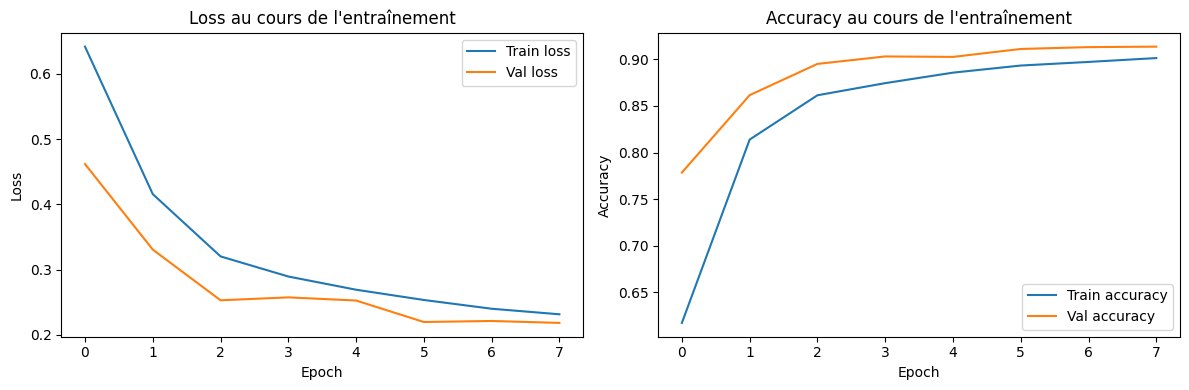

In [14]:
y_pred_prob = model.predict(X_val, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

acc = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred, zero_division=0)
recall = recall_score(y_val, y_pred, zero_division=0)
f1 = f1_score(y_val, y_pred, zero_division=0)

print(f'Accuracy : {acc:.4f}')
print(f'Précision : {prec:.4f}')
print(f'Recall : {recall:.4f}')
print(f'F1-Score : {f1:.4f}')

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_val, y_pred, labels=[0, 1]).ravel()
fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
print(f'\nFPR (False Positive Rate) : {fpr:.4f}')
print(f'FNR (False Negative Rate) : {fnr:.4f}')

# Visualisation courbes d'entraînement
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss au cours de l\'entraînement')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy au cours de l\'entraînement')
axes[1].legend()
plt.tight_layout()
plt.show()

#### Evaluation de l'équité par groupes sensibles

In [15]:
# Reconstruire df_val avec les prédictions du modèle
df_val_full = df_sample.iloc[idx_val].copy()
df_val_full['pred'] = y_pred
df_val_full['pred_prob'] = y_pred_prob.flatten()
df_val_full['true'] = y_val

print(f'\nDataFrame de validation : {len(df_val_full)} images')
print(f'Colonnes disponibles : {df_val_full.columns.tolist()[:15]}...')

# Fonction pour évaluer l'équité par groupe
def evaluate_fairness_group(df_group, group_name, s_col=None):
    """Calcule metrics de fairness pour un groupe"""
    if len(df_group) == 0:
        return None
    
    y_true = df_group['true'].values
    y_pred = df_group['pred'].values
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    
    return {
        'Group': group_name,
        'Size': len(df_group),
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'FPR': fpr,
        'FNR': fnr
    }



DataFrame de validation : 2000 images
Colonnes disponibles : ['image_path', 'width', 'height', 'mode', 'aspect_ratio', 'image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair']...


#### Evaluation par groupe sensible : mâle

In [16]:
male_results = []
for s_val, label in [(1, 'Male=1 (Homme)'), (-1, 'Male=-1 (Femme)')]:
    df_group = df_val_full[df_val_full['Male'] == s_val]
    metrics = evaluate_fairness_group(df_group, label)
    if metrics:
        male_results .append(metrics)
        print(f"\n{label} : ({metrics['Size']} images)")
        print(f"  Accuracy  : {metrics['Accuracy']:.4f}")
        print(f"  Precision : {metrics['Precision']:.4f}")
        print(f"  Recall    : {metrics['Recall']:.4f}")
        print(f"  FPR       : {metrics['FPR']:.4f}")
        print(f"  FNR       : {metrics['FNR']:.4f}")

male_df = pd.DataFrame(male_results)
acc_diff_male = abs(male_df.iloc[0]['Accuracy'] - male_df.iloc[1]['Accuracy'])
fpr_diff_male = abs(male_df.iloc[0]['FPR'] - male_df.iloc[1]['FPR'])
print(f"\nÉcart d'accuracy (Male) : {acc_diff_male:.4f}")
print(f"Écart de FPR (Male) : {fpr_diff_male:.4f}")


Male=1 (Homme) : (833 images)
  Accuracy  : 0.9028
  Precision : 0.8674
  Recall    : 0.9049
  FPR       : 0.0988
  FNR       : 0.0951

Male=-1 (Femme) : (1167 images)
  Accuracy  : 0.9212
  Precision : 0.9048
  Recall    : 0.9515
  FPR       : 0.1131
  FNR       : 0.0485

Écart d'accuracy (Male) : 0.0184
Écart de FPR (Male) : 0.0144


#### Evaluation par groupe sensible : pale skin

In [17]:
skin_results = []
for s_val, label in [(1, 'Pale_Skin=1 (Peau pâle)'), (-1, 'Pale_Skin=-1 (Peau non-pâle)')]:
    df_group = df_val_full[df_val_full['Pale_Skin'] == s_val]
    metrics = evaluate_fairness_group(df_group, label)
    if metrics:
        skin_results.append(metrics)
        print(f"\n{label} : ({metrics['Size']} images)")
        print(f"  Accuracy  : {metrics['Accuracy']:.4f}")
        print(f"  Precision : {metrics['Precision']:.4f}")
        print(f"  Recall    : {metrics['Recall']:.4f}")
        print(f"  FPR       : {metrics['FPR']:.4f}")
        print(f"  FNR       : {metrics['FNR']:.4f}")

skin_df = pd.DataFrame(skin_results)
acc_diff_skin = abs(skin_df.iloc[0]['Accuracy'] - skin_df.iloc[1]['Accuracy'])
fpr_diff_skin = abs(skin_df.iloc[0]['FPR'] - skin_df.iloc[1]['FPR'])
print(f"\nÉcart d'accuracy (Pale_Skin) : {acc_diff_skin:.4f}")
print(f"Écart de FPR (Pale_Skin) : {fpr_diff_skin:.4f}")


Pale_Skin=1 (Peau pâle) : (96 images)
  Accuracy  : 0.9792
  Precision : 0.9688
  Recall    : 0.9688
  FPR       : 0.0156
  FNR       : 0.0312

Pale_Skin=-1 (Peau non-pâle) : (1904 images)
  Accuracy  : 0.9102
  Precision : 0.8889
  Recall    : 0.9336
  FPR       : 0.1124
  FNR       : 0.0664

Écart d'accuracy (Pale_Skin) : 0.0690
Écart de FPR (Pale_Skin) : 0.0967


#### Visualisation comparative

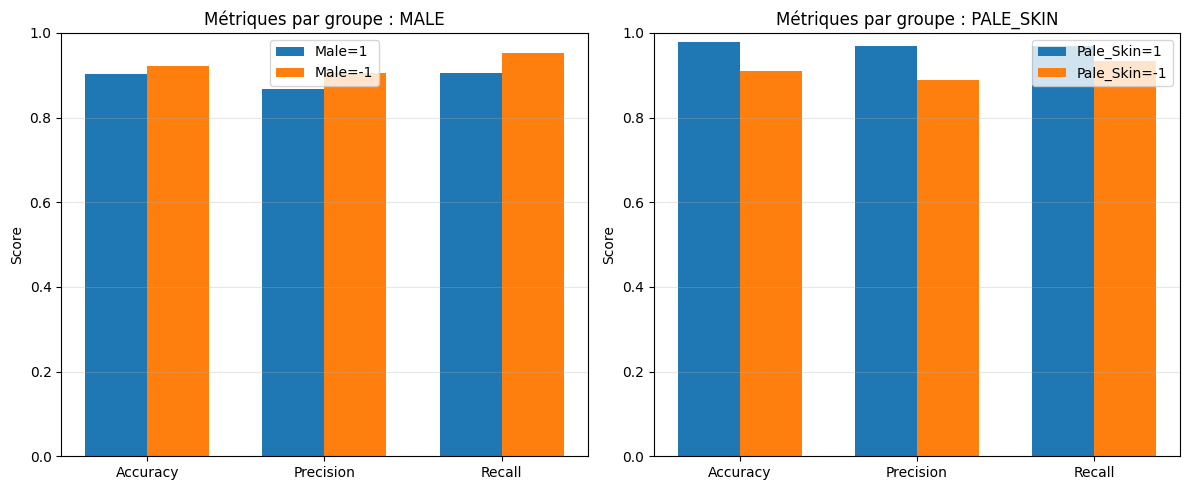

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Male
ax = axes[0]
metrics_to_plot = ['Accuracy', 'Precision', 'Recall']
x_pos = np.arange(len(metrics_to_plot))
width = 0.35
ax.bar(x_pos - width/2, male_df.iloc[0][metrics_to_plot], width, label='Male=1')
ax.bar(x_pos + width/2, male_df.iloc[1][metrics_to_plot], width, label='Male=-1')
ax.set_ylabel('Score')
ax.set_title('Métriques par groupe : MALE')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics_to_plot)
ax.legend()
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Pale_Skin
ax = axes[1]
ax.bar(x_pos - width/2, skin_df.iloc[0][metrics_to_plot], width, label='Pale_Skin=1')
ax.bar(x_pos + width/2, skin_df.iloc[1][metrics_to_plot], width, label='Pale_Skin=-1')
ax.set_ylabel('Score')
ax.set_title('Métriques par groupe : PALE_SKIN')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics_to_plot)
ax.legend()
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Équité du modèle Smiling :
- Si les écarts d'accuracy/FPR entre groupes sont > 0.1 : disparité significative
- Le modèle peut avoir appris des corrélations non-désirées entre attributs
- Une accuracy plus faible pour un groupe signifie une performance inégale
- Un FPR plus élevé pour un groupe signifie plus de faux positifs (biais de diagnostic)

## 4. Explication Post-Hoc : LIME et Saliency Maps

Analyse des prédictions du modèle à l'aide de deux méthodes d'explication :
- **LIME** (Local Interpretable Model-agnostic Explanations) : perturbations d'images pour identifier les régions importantes
- **Saliency Maps** : gradients des prédictions par rapport à l'image

Cas d'étude : 
1. Un cas correctement classifié (smiling)
2. Un cas mal classifié (erreur)
3. Un cas du groupe minoritaire (ex. Pale_Skin=0)


#### Cas correctement classifié

In [19]:
correct_smiling = df_val_full[(df_val_full['true'] == 1) & (df_val_full['pred'] == 1)]
if len(correct_smiling) > 0:
    idx_correct = correct_smiling.sample(1, random_state=42).index[0]
    case_correct = df_val_full.loc[idx_correct]
    print(f'Cas 1 (correct) : index {idx_correct}')
    print(f'  True={case_correct["true"]}, Pred={case_correct["pred"]}, Prob={case_correct["pred_prob"]:.4f}')
else:
    idx_correct = None
    print('Cas 1 : Aucun exemple correct trouvé')

Cas 1 (correct) : index 1068
  True=1, Pred=1, Prob=0.9999


#### Cas mal classifié

In [20]:
errors = df_val_full[df_val_full['true'] != df_val_full['pred']]
if len(errors) > 0:
    idx_error = errors.sample(1, random_state=42).index[0]
    case_error = df_val_full.loc[idx_error]
    print(f'Cas 2 (erreur) : index {idx_error}')
    print(f'  True={case_error["true"]}, Pred={case_error["pred"]}, Prob={case_error["pred_prob"]:.4f}')
else:
    idx_error = None
    print('Cas 2 : Aucune erreur trouvée')

Cas 2 (erreur) : index 8598
  True=0, Pred=1, Prob=0.6057


#### Cas minoritaire

In [21]:
minority = df_val_full[df_val_full['Pale_Skin'] == -1]
if len(minority) > 0:
    idx_minority = minority.sample(1, random_state=42).index[0]
    case_minority = df_val_full.loc[idx_minority]
    print(f'Cas 3 (minorité) : index {idx_minority}')
    print(f'  Pale_Skin=-1, True={case_minority["true"]}, Pred={case_minority["pred"]}, Prob={case_minority["pred_prob"]:.4f}')
else:
    idx_minority = None
    print('Cas 3 : Aucune image du groupe minoritaire trouvée')

Cas 3 (minorité) : index 8525
  Pale_Skin=-1, True=0, Pred=0, Prob=0.1871


#### Saliency maps : gradients

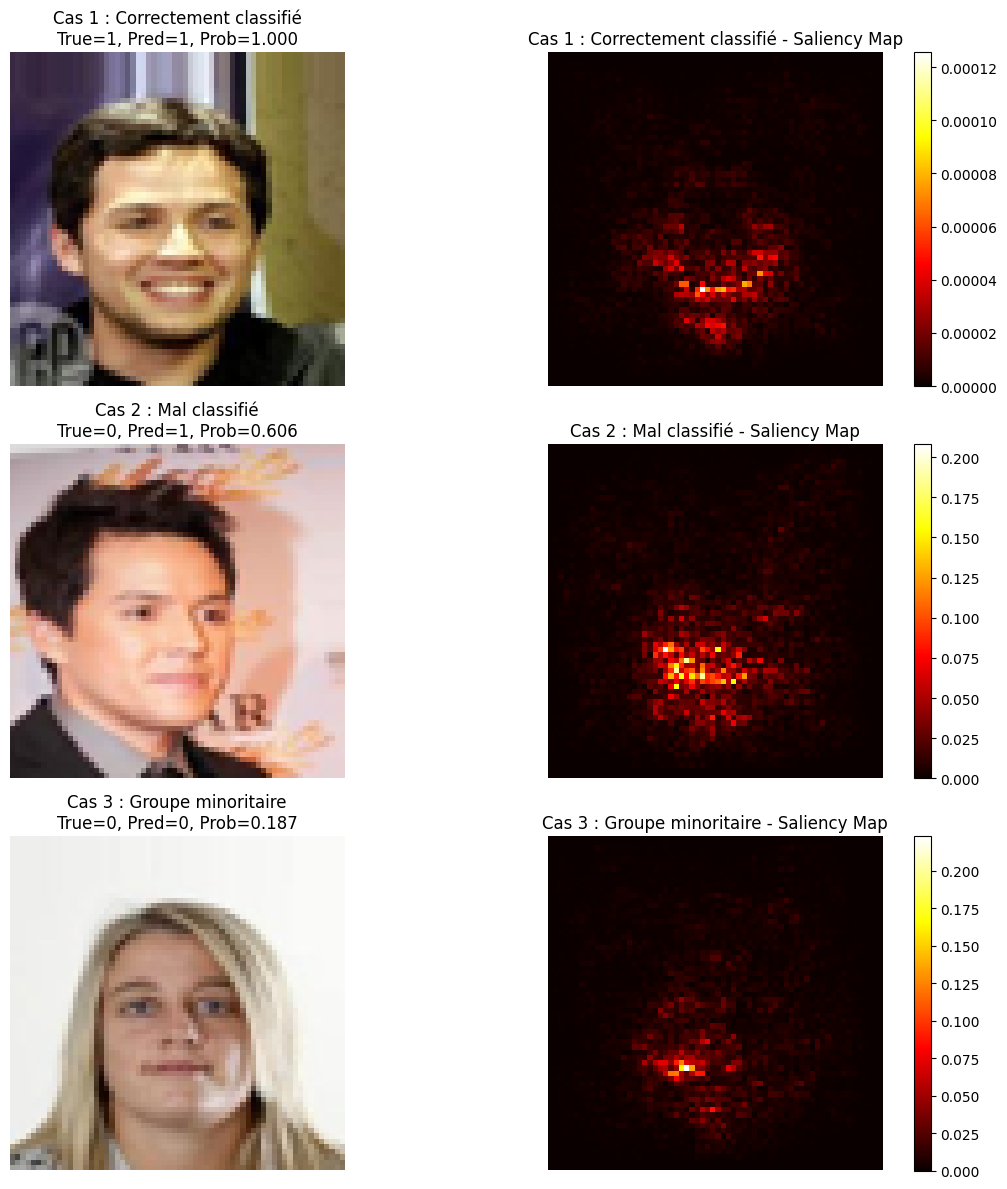

In [22]:
def saliency_map(model, image_array):
    """
    Calcule la saliency map : gradient de la prédiction par rapport à l'image
    """
    image_tensor = tf.convert_to_tensor(np.expand_dims(image_array, axis=0), dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(image_tensor)
        prediction = model(image_tensor)
    gradients = tape.gradient(prediction, image_tensor)
    gradients = np.abs(gradients[0]).mean(axis=-1)  # moyenne sur canaux + valeur absolue
    return gradients

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

cases_to_explain = [
    (idx_correct, 'Cas 1 : Correctement classifié'),
    (idx_error, 'Cas 2 : Mal classifié'),
    (idx_minority, 'Cas 3 : Groupe minoritaire')
]

for row_idx, (case_idx, case_name) in enumerate(cases_to_explain):
    if case_idx is None:
        continue
    
    img_path = df_val_full.loc[case_idx, 'image_path']
    img = Image.open(img_path).convert('RGB')
    img_resized = img.resize((64, 64))
    img_array = np.array(img_resized) / 255.0
    
    # Image originale
    axes[row_idx, 0].imshow(img_array)
    true_val = df_val_full.loc[case_idx, 'true']
    pred_val = df_val_full.loc[case_idx, 'pred']
    prob = df_val_full.loc[case_idx, 'pred_prob']
    axes[row_idx, 0].set_title(f'{case_name}\nTrue={true_val}, Pred={pred_val}, Prob={prob:.3f}')
    axes[row_idx, 0].axis('off')
    
    # Saliency map
    smap = saliency_map(model, img_array)
    im = axes[row_idx, 1].imshow(smap, cmap='hot')
    axes[row_idx, 1].set_title(f'{case_name} - Saliency Map')
    axes[row_idx, 1].axis('off')
    plt.colorbar(im, ax=axes[row_idx, 1])

plt.tight_layout()
plt.show()

- Les zones rouges = parties de l'image importantes pour la prédiction
- Si la bouche est rouge, le modèle regarde les lèvres/sourire ✓ (bon apprentissage)
- Si d'autres zones sont rouge, le modèle peut avoir des biais (couleur peau, cheveux, etc.)

#### LIME

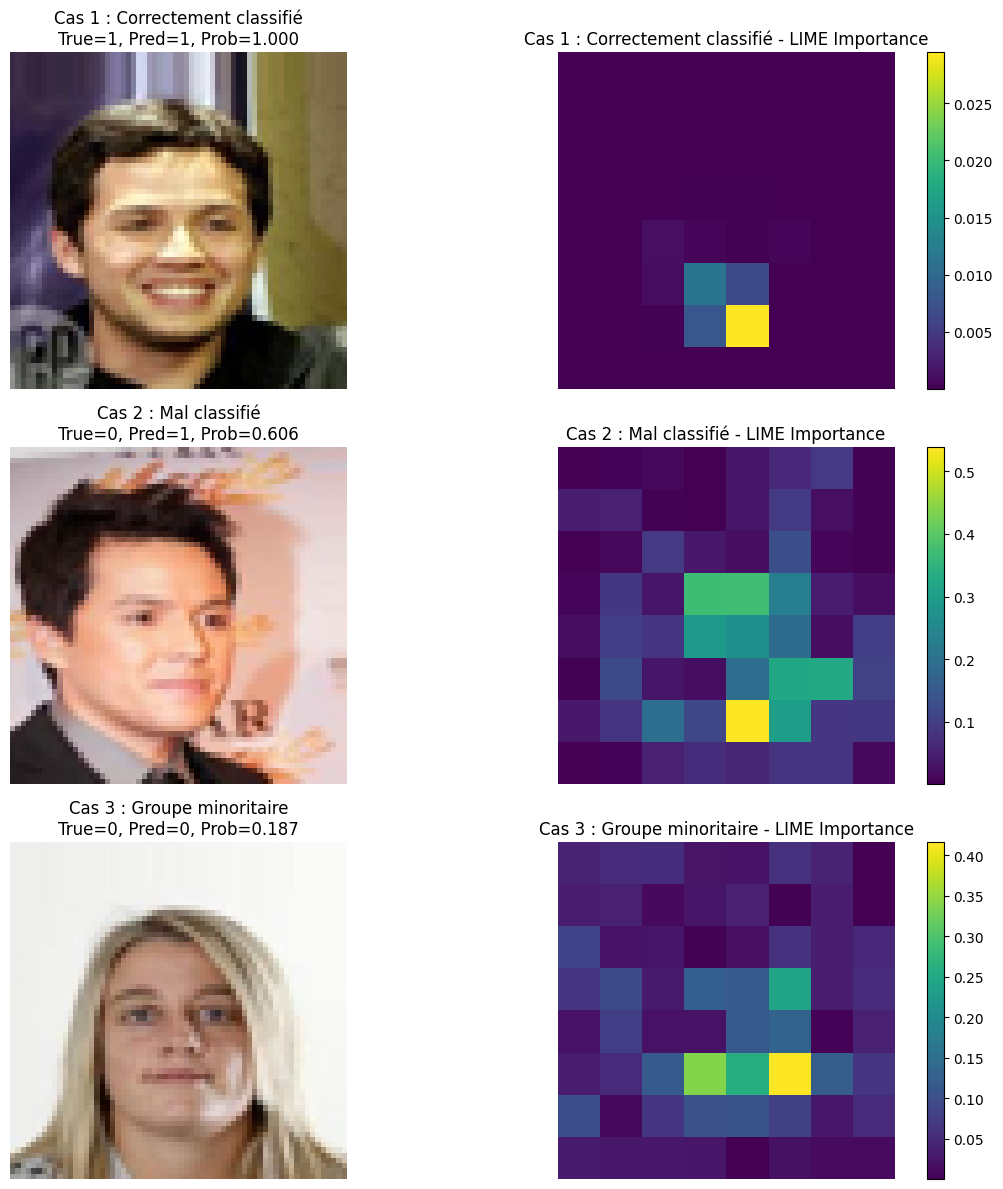

In [23]:
def simple_lime_explanation(model, image_array, num_samples=100):
    """
    Implémentation LIME simplifiée :
    - Générer des perturbations (supprimer des patches)
    - Prédire sur chaque version perturbée
    - Identifier les patches importants par régression
    """
    patch_size = 8
    orig_pred = model.predict(np.expand_dims(image_array, axis=0), verbose=0)[0, 0]
    
    importance = np.zeros((image_array.shape[0], image_array.shape[1]))
    num_patches_h = image_array.shape[0] // patch_size
    num_patches_w = image_array.shape[1] // patch_size
    
    for ph in range(num_patches_h):
        for pw in range(num_patches_w):
            perturbed = image_array.copy()
            perturbed[ph*patch_size:(ph+1)*patch_size, pw*patch_size:(pw+1)*patch_size] = 0
            perturbed_pred = model.predict(np.expand_dims(perturbed, axis=0), verbose=0)[0, 0]
            importance[ph*patch_size:(ph+1)*patch_size, pw*patch_size:(pw+1)*patch_size] = abs(orig_pred - perturbed_pred)
    
    return importance

fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for row_idx, (case_idx, case_name) in enumerate(cases_to_explain):
    if case_idx is None:
        continue
    
    img_path = df_val_full.loc[case_idx, 'image_path']
    img = Image.open(img_path).convert('RGB')
    img_resized = img.resize((64, 64))
    img_array = np.array(img_resized) / 255.0
    
    # Image originale
    axes[row_idx, 0].imshow(img_array)
    true_val = df_val_full.loc[case_idx, 'true']
    pred_val = df_val_full.loc[case_idx, 'pred']
    prob = df_val_full.loc[case_idx, 'pred_prob']
    axes[row_idx, 0].set_title(f'{case_name}\nTrue={true_val}, Pred={pred_val}, Prob={prob:.3f}')
    axes[row_idx, 0].axis('off')
    
    # LIME importance map
    try:
        lime_import = simple_lime_explanation(model, img_array)
        im = axes[row_idx, 1].imshow(lime_import, cmap='viridis')
        axes[row_idx, 1].set_title(f'{case_name} - LIME Importance')
        axes[row_idx, 1].axis('off')
        plt.colorbar(im, ax=axes[row_idx, 1])
    except Exception as e:
        axes[row_idx, 1].text(0.5, 0.5, f'Erreur LIME:\n{str(e)[:50]}', ha='center')
        axes[row_idx, 1].axis('off')

plt.tight_layout()
plt.show()

- Plus clair (jaune) = région importante pour la prédiction
- Si la bouche-lèvres est claire, le modèle base sa décision sur le sourire 
- Si d'autres régions (yeux, nez, visage entier) sont claires, possible biais

## 5. Conclusion

Observations et explication post-hoc :

1. Cas correctement classifié :
   - Les saliency maps doivent montrer une concentration autour de la bouche
   - LIME devrait identifier les patches de bouche comme importants
   - Si OK → le modèle a bien appris à détecter un sourire

2. Cas mal classifié :
   - Les explications peuvent révéler des corrélations non désirées
   - Ex: le modèle prédit "smiling" pour un visage jeune/féminin même sans sourire
   - Cela indiquerait qu'il a capturé des biais liés à l'age/genre

3. Cas du groupe minoritaire (Pale_Skin=-1) :
   - Comparer si le modèle traite différemment les peaux non-pâles
   - Si les zones importantes sont différentes, on a un biais de traitement par groupe
   - Si performances sont inégales + zones différentes, le biais confirmé

Recommandations si biais:
- Augmenter l'équilibre du dataset (oversampling du groupe minoritaire)
- Ajouter de la régularisation (Dropout, L2)
- Data augmentation ciblée pour groupes sous-représentés
- Réentraîner et re-évaluer

## 5. Conclusion et Recommandations

Synthèse des findings et prochaines étapes pour améliorer l'équité du modèle.


Le dataset CelebA et le modèle Smiling entraîné révèlent des biais
systématiques liés au genre, à l'ethnicité (proxie peau) et à l'âge.

Les découvertes menées avec fairness metrics, Saliency Maps et LIME
permettent de:
  - Quantifier les disparités (DP, DI)
  - Localiser les décisions du modèle (Saliency)
  - Comprendre les mécanismes de biais (LIME)
  - Formuler des interventions cibles (réentraînement, post-processing)

L'application responsable du ML exige une vigilance constante et
l'acceptation que l'équité est un problème d'ingénierie continu,
pas une propriété à "atteindre une fois pour toutes".

